# Self-exciting hurdle model: adversarial validation

This notebook treats the exponentially weighted history state as a scientific hypothesis rather than merely another fitted feature. It uses exact nested ablations, repeated nested scholar-level cross-validation, full-pipeline bootstrap, held-out generative checks, finite-order and latent-heterogeneity alternatives, distributed-lag validation, and temporal placebos.

Set `PAPER_RUN = True` for final estimates. The default reduced mode executes every section with fewer repetitions.

In [1]:
# Cell 0: imports, paths, and validation controls

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize, lsq_linear
from scipy.special import expit
from scipy.spatial import cKDTree

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.model_selection import KFold, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAME = 'Self-Exciting-Hurdle-S'
MODEL_TAG = 'self_exciting_hurdle_validation'

SEED = 63
EPS = 0.49
Y = 20
DPI = 300
PAPER_RUN = True

OUTER_SPLITS = 5
INNER_SPLITS = 5 if PAPER_RUN else 4
OUTER_REPEATS = 5 if PAPER_RUN else 1
RHO_GRID = np.linspace(0.0, 0.98, 50 if PAPER_RUN else 12)
RESIDUAL_FAMILIES = ['normal', 'laplace'] if PAPER_RUN else ['normal']

N_PIPE_BOOT = 500 if PAPER_RUN else 25
N_GENERATIVE_REPS = 100 if PAPER_RUN else 10
N_LAG_BOOT = 500 if PAPER_RUN else 30
N_PLACEBO = 500 if PAPER_RUN else 30
N_NULL = 200 if PAPER_RUN else 15
N_PRED_BOOT = 2000 if PAPER_RUN else 200
N_CK_PERM = 2000 if PAPER_RUN else 250
N_MARKOV_REPS = 500 if PAPER_RUN else 50

COMPLETE_CASE_ONLY = True
MISSING_AS_ZERO = False
CONSTRAIN_GENERATOR = True
RIDGE = 1e-6
MIN_PROB = 1e-9

TASK_ROOT = Path.cwd().parent
DATA = TASK_ROOT/'input'
OUTPUT = TASK_ROOT/'output'
RESULT_DIR = OUTPUT/'results'/MODEL_TAG
FIG_DIR = OUTPUT/'figures'/MODEL_TAG
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Validation mode: {"paper" if PAPER_RUN else "reduced"}')
print(f'Input: {DATA}')
print(f'Results: {RESULT_DIR}')

Validation mode: paper
Input: /Users/samlunemagid/Desktop/SPAARW2/se adversary/input
Results: /Users/samlunemagid/Desktop/SPAARW2/se adversary/output/results/self_exciting_hurdle_validation


In [2]:
# Cell 1: data preparation and missingness audit

raw = pd.read_csv(DATA/'df_traj_all.csv')
raw['CareerAgeZero'] = pd.to_numeric(raw['CareerAgeZero'], errors='coerce')
raw['pubs_adj'] = pd.to_numeric(raw['pubs_adj'], errors='coerce').clip(lower=0)
raw = raw.dropna(subset=['dblp_id', 'CareerAgeZero', 'pubs_adj'])

full_ids = raw.groupby('dblp_id')['CareerAgeZero'].max().loc[lambda s: s.eq(Y)].index
prepared = raw[raw['dblp_id'].isin(full_ids)].copy()
prepared = prepared.groupby(['dblp_id', 'CareerAgeZero'], as_index=False)['pubs_adj'].sum()

panel_raw = prepared.pivot(index='dblp_id', columns='CareerAgeZero', values='pubs_adj').reindex(columns=np.arange(Y + 1)).sort_index()
missing_by_scholar = panel_raw.isna().sum(axis=1)

data_audit = pd.DataFrame({
    'raw_rows': [len(raw)],
    'eligible_scholars': [len(panel_raw)],
    'complete_scholars': [int(missing_by_scholar.eq(0).sum())],
    'scholars_with_internal_missingness': [int(missing_by_scholar.gt(0).sum())],
    'missing_person_years': [int(panel_raw.isna().sum().sum())],
    'duplicate_rows_collapsed': [int(len(raw[raw['dblp_id'].isin(full_ids)]) - len(prepared))]
})

if COMPLETE_CASE_ONLY:
    panel = panel_raw.dropna().copy()
elif MISSING_AS_ZERO:
    panel = panel_raw.fillna(0.0).copy()
else:
    raise ValueError('Missing scholar-years remain. Set COMPLETE_CASE_ONLY=True or explicitly set MISSING_AS_ZERO=True.')

Q_EMP = panel.to_numpy(dtype=float)
EMP_IDS = panel.index.to_numpy()
N_EMP = len(panel)

data_audit['analysis_scholars'] = N_EMP
data_audit.to_csv(RESULT_DIR/'data_audit.csv', index=False)

print(f'Analysis panel: {N_EMP} scholars x {Q_EMP.shape[1]} years')
print(f'Observed zero fraction: {(Q_EMP == 0).mean():.3f}')
display(data_audit)

Analysis panel: 510 scholars x 21 years
Observed zero fraction: 0.139


,raw_rows,eligible_scholars,complete_scholars,scholars_with_internal_missingness,missing_person_years,duplicate_rows_collapsed,analysis_scholars
0,29119,591,510,81,315,0,510


In [3]:
# Cell 2: stages, memory states, lags, and exact model variants

STAGE_ORDER = ['0', '1-4', '5-7', '8-20']


def transition_stage(t):
    if t == 0:
        return '0'
    if 1 <= t <= 4:
        return '1-4'
    if 5 <= t <= 7:
        return '5-7'
    if 8 <= t <= 19:
        return '8-20'
    raise ValueError(f'No stage for transition {t}')


def history_panel(q, rho, kind='normalized'):
    q = np.asarray(q, dtype=float)
    history = np.zeros_like(q)
    numerator = np.zeros(q.shape[0])
    denominator = np.zeros(q.shape[0])

    for target_year in range(1, q.shape[1]):
        if kind == 'normalized':
            history[:, target_year] = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)
        elif kind == 'additive':
            history[:, target_year] = numerator
        else:
            raise ValueError(f'Unknown history kind: {kind}')

        q_prev = q[:, target_year - 1]
        numerator = rho * numerator + np.log1p(q_prev)
        denominator = rho * denominator + 1.0

    return history


def build_transition_rows(q, history=None, scholar_ids=None):
    q = np.asarray(q, dtype=float)
    history = np.zeros_like(q) if history is None else np.asarray(history, dtype=float)
    scholar_ids = np.arange(q.shape[0]) if scholar_ids is None else np.asarray(scholar_ids)
    pieces = []

    for target_year in range(1, q.shape[1]):
        transition_year = target_year - 1
        q_prev = q[:, transition_year]
        q_now = q[:, target_year]
        d = {
            'scholar': np.arange(q.shape[0]),
            'scholar_id': scholar_ids,
            'transition_year': transition_year,
            'target_year': target_year,
            'stage': transition_stage(transition_year),
            'q_prev': q_prev,
            'q': q_now,
            'active': (q_now > 0).astype(int),
            'x_prev': np.log1p(q_prev),
            'prev_active': (q_prev > 0).astype(int),
            'restart': (q_prev <= 0).astype(int),
            'history': history[:, target_year]
        }

        for lag in range(2, 5):
            source_year = target_year - lag
            available = source_year >= 0
            lag_q = q[:, source_year] if available else np.zeros(q.shape[0])
            d[f'x_lag{lag}'] = np.log1p(lag_q)
            d[f'active_lag{lag}'] = (lag_q > 0).astype(int)
            d[f'lag{lag}_available'] = int(available)

        pieces.append(pd.DataFrame(d))

    return pd.concat(pieces, ignore_index=True)


VARIANTS = {
    'M0': {'activity_history': False, 'positive_history': False, 'ar_order': 1},
    'MA': {'activity_history': True, 'positive_history': False, 'ar_order': 1},
    'MQ': {'activity_history': False, 'positive_history': True, 'ar_order': 1},
    'MAQ': {'activity_history': True, 'positive_history': True, 'ar_order': 1},
    'AR2': {'activity_history': False, 'positive_history': False, 'ar_order': 2},
    'AR3': {'activity_history': False, 'positive_history': False, 'ar_order': 3},
    'AR4': {'activity_history': False, 'positive_history': False, 'ar_order': 4}
}

PRIMARY_VARIANTS = ['M0', 'MA', 'MQ', 'MAQ', 'AR2', 'AR3', 'AR4']


def feature_names(variant):
    spec = VARIANTS[variant]
    activity = ['x_prev', 'prev_active']
    positive = ['x_prev', 'restart']

    for lag in range(2, spec['ar_order'] + 1):
        activity += [f'x_lag{lag}', f'active_lag{lag}', f'lag{lag}_available']
        positive += [f'x_lag{lag}', f'lag{lag}_available']

    if spec['activity_history']:
        activity.append('history')
    if spec['positive_history']:
        positive.append('history')

    return activity, positive


CONTINUOUS = {'x_prev', 'history', 'x_lag2', 'x_lag3', 'x_lag4'}

In [4]:
# Cell 3: fitting, likelihood scoring, and coefficient recovery


def fit_scaler(data, names):
    means, scales = {}, {}

    for name in names:
        if name in CONTINUOUS:
            means[name] = float(data[name].mean())
            scale = float(data[name].std(ddof=0))
            scales[name] = scale if np.isfinite(scale) and scale > 1e-8 else 1.0
        else:
            means[name], scales[name] = 0.0, 1.0

    return means, scales


def design_matrix(data, names, means, scales):
    cols = [np.ones(len(data))]

    for name in names:
        values = data[name].to_numpy(dtype=float)
        cols.append((values - means[name]) / scales[name])

    return np.column_stack(cols)


def array_design(values, fitted):
    n = len(next(iter(values.values())))
    cols = [np.ones(n)]

    for name in fitted['feature_names']:
        values_array = np.asarray(values[name], dtype=float)
        cols.append(
            (values_array - fitted['means'][name])
            / fitted['scales'][name]
        )

    return np.column_stack(cols)


def fit_logistic(X, y, constrained_index=None):
    y = np.asarray(y, dtype=float)

    if np.unique(y).size == 1:
        p = np.clip(
            (y.sum() + 0.5) / (len(y) + 1),
            1e-6,
            1 - 1e-6
        )

        coef = np.zeros(X.shape[1])
        coef[0] = np.log(p / (1 - p))
        return coef

    def objective(weights):
        eta = np.clip(X @ weights, -35, 35)
        p = expit(eta)

        nll = -np.sum(
            y * np.log(p + 1e-12)
            + (1 - y) * np.log(1 - p + 1e-12)
        )

        nll += RIDGE * np.sum(weights[1:] ** 2)

        grad = X.T @ (p - y)
        grad[1:] += 2 * RIDGE * weights[1:]

        return nll, grad

    bounds = [(None, None)] * X.shape[1]

    if constrained_index is not None:
        bounds[constrained_index] = (0, None)

    result = minimize(
        objective,
        np.zeros(X.shape[1]),
        jac=True,
        method='L-BFGS-B',
        bounds=bounds,
        options={
            'maxiter': 5000,
            'maxls': 100,
            'ftol': 1e-10,
            'gtol': 1e-7
        }
    )

    if not result.success:
        warnings.warn(
            f'Logistic fit warning: {result.message}'
        )

    return result.x


def fit_positive(X, y, family='normal', constrained_index=None):
    y = np.asarray(y, dtype=float)
    family = family.lower()

    if len(y) == 0:
        raise ValueError('Positive-outcome regression received no observations.')

    lower = np.full(X.shape[1], -np.inf)
    upper = np.full(X.shape[1], np.inf)

    if constrained_index is not None:
        lower[constrained_index] = 0.0

    bounds = list(zip(lower, upper))

    initial = lsq_linear(
        X,
        y,
        bounds=(lower, upper),
        lsq_solver='exact'
    ).x

    if family == 'normal':
        coef = initial

    elif family == 'laplace':
        smooth = 1e-6

        def objective(weights):
            resid = y - X @ weights
            abs_smooth = np.sqrt(resid ** 2 + smooth)

            loss = np.sum(abs_smooth)
            loss += RIDGE * np.sum(weights[1:] ** 2)

            grad = -X.T @ (resid / abs_smooth)
            grad[1:] += 2 * RIDGE * weights[1:]

            return loss, grad

        result = minimize(
            objective,
            initial,
            jac=True,
            method='L-BFGS-B',
            bounds=bounds,
            options={
                'maxiter': 5000,
                'maxls': 100,
                'ftol': 1e-10,
                'gtol': 1e-7
            }
        )

        if not result.success:
            powell = minimize(
                lambda weights: objective(weights)[0],
                result.x if np.all(np.isfinite(result.x)) else initial,
                method='Powell',
                bounds=bounds,
                options={
                    'maxiter': 10000,
                    'xtol': 1e-8,
                    'ftol': 1e-10
                }
            )

            if (
                np.all(np.isfinite(powell.x))
                and np.isfinite(powell.fun)
                and (
                    not np.isfinite(result.fun)
                    or powell.fun <= result.fun
                )
            ):
                result = powell

        coef = result.x

        if not result.success:
            warnings.warn(
                'Laplace regression warning: '
                f'{result.message}; '
                f'objective={result.fun:.6g}'
            )

        if not np.all(np.isfinite(coef)):
            raise RuntimeError(
                'Laplace regression returned non-finite coefficients.'
            )

    else:
        raise ValueError(
            f'Unknown residual family: {family}'
        )

    residuals = y - X @ coef

    # Keep the fitted intercept and residual distribution aligned.
    if family == 'normal':
        residual_center = float(np.mean(residuals))
    else:
        residual_center = float(np.median(residuals))

    coef = coef.copy()
    coef[0] += residual_center
    residuals = y - X @ coef

    sigma = max(
        float(np.sqrt(np.mean(residuals ** 2))),
        1e-8
    )

    laplace_scale = max(
        float(np.mean(np.abs(residuals))),
        1e-8
    )

    return coef, residuals, sigma, laplace_scale


def fit_stage(
    stage_data,
    variant='MAQ',
    family='normal',
    constrain_history=True
):
    activity_features, positive_features = feature_names(variant)

    act_means, act_scales = fit_scaler(
        stage_data,
        activity_features
    )

    X_act = design_matrix(
        stage_data,
        activity_features,
        act_means,
        act_scales
    )

    y_act = stage_data['active'].to_numpy(dtype=float)

    act_history_index = None

    if constrain_history and 'history' in activity_features:
        act_history_index = (
            1 + activity_features.index('history')
        )

    activity_coef = fit_logistic(
        X_act,
        y_act,
        act_history_index
    )

    positive = stage_data[
        stage_data['active'].eq(1)
    ].copy()

    if positive.empty:
        raise ValueError(
            'No positive observations available for '
            f'stage containing {len(stage_data)} transitions.'
        )

    pos_means, pos_scales = fit_scaler(
        positive,
        positive_features
    )

    X_pos = design_matrix(
        positive,
        positive_features,
        pos_means,
        pos_scales
    )

    y_pos = np.log(
        positive['q'].to_numpy(dtype=float)
    )

    pos_history_index = None

    if constrain_history and 'history' in positive_features:
        pos_history_index = (
            1 + positive_features.index('history')
        )

    positive_coef, residuals, sigma, laplace_scale = fit_positive(
        X_pos,
        y_pos,
        family,
        pos_history_index
    )

    return {
        'activity': {
            'feature_names': activity_features,
            'means': act_means,
            'scales': act_scales,
            'coef': activity_coef,
            'n': len(stage_data)
        },
        'positive': {
            'feature_names': positive_features,
            'means': pos_means,
            'scales': pos_scales,
            'coef': positive_coef,
            'residuals': residuals,
            'sigma': sigma,
            'laplace_scale': laplace_scale,
            'family': family.lower(),
            'n': len(positive)
        }
    }


def fit_model(
    q,
    history=None,
    variant='MAQ',
    family='normal',
    constrain_history=True
):
    rows = build_transition_rows(q, history)

    return {
        stage: fit_stage(
            rows[rows['stage'].eq(stage)],
            variant,
            family,
            constrain_history
        )
        for stage in STAGE_ORDER
    }


def positive_nll(resid, fitted):
    family = fitted['family']

    if family == 'normal':
        sigma = fitted['sigma']

        return (
            0.5 * (resid / sigma) ** 2
            + np.log(sigma)
            + 0.5 * np.log(2 * np.pi)
        )

    if family == 'laplace':
        scale = fitted['laplace_scale']

        return (
            np.abs(resid) / scale
            + np.log(2 * scale)
        )

    raise ValueError(
        f'Unknown residual family: {family}'
    )


def score_model_details(
    model,
    q,
    history=None,
    scholar_ids=None
):
    rows = build_transition_rows(
        q,
        history,
        scholar_ids
    )

    pieces = []

    for stage in STAGE_ORDER:
        d = rows[
            rows['stage'].eq(stage)
        ].copy()

        fitted = model[stage]

        X_act = design_matrix(
            d,
            fitted['activity']['feature_names'],
            fitted['activity']['means'],
            fitted['activity']['scales']
        )

        p = np.clip(
            expit(X_act @ fitted['activity']['coef']),
            MIN_PROB,
            1 - MIN_PROB
        )

        y = d['active'].to_numpy(dtype=float)

        act_nll = -(
            y * np.log(p)
            + (1 - y) * np.log(1 - p)
        )

        d['p_active'] = p
        d['activity_nll'] = act_nll
        d['positive_nll'] = 0.0
        d['mu_log_q'] = np.nan
        d['residual'] = np.nan
        d['residual_scale'] = np.nan
        d['residual_family'] = fitted['positive']['family']

        mask = d['active'].eq(1).to_numpy()

        if mask.any():
            positive = d.loc[mask]

            X_pos = design_matrix(
                positive,
                fitted['positive']['feature_names'],
                fitted['positive']['means'],
                fitted['positive']['scales']
            )

            y_pos = np.log(
                positive['q'].to_numpy(dtype=float)
            )

            mu = X_pos @ fitted['positive']['coef']
            resid = y_pos - mu

            d.loc[mask, 'positive_nll'] = positive_nll(
                resid,
                fitted['positive']
            )

            d.loc[mask, 'mu_log_q'] = mu
            d.loc[mask, 'residual'] = resid

            if fitted['positive']['family'] == 'normal':
                residual_scale = fitted['positive']['sigma']
            else:
                residual_scale = fitted['positive']['laplace_scale']

            d.loc[mask, 'residual_scale'] = residual_scale

        d['total_nll'] = (
            d['activity_nll']
            + d['positive_nll']
        )

        pieces.append(d)

    return pd.concat(
        pieces,
        ignore_index=True
    )


def score_model(model, q, history=None):
    details = score_model_details(
        model,
        q,
        history
    )

    return float(
        details['total_nll'].mean()
    )


def original_scale_coefficients(fitted):
    values = {
        'intercept': float(fitted['coef'][0])
    }

    for j, name in enumerate(
        fitted['feature_names'],
        start=1
    ):
        scale = fitted['scales'][name]
        mean = fitted['means'][name]

        values[name] = float(
            fitted['coef'][j] / scale
        )

        values['intercept'] -= float(
            fitted['coef'][j]
            * mean
            / scale
        )

    return values


def parameter_table(
    model,
    variant,
    rho,
    family,
    label=None
):
    rows = []

    for stage in STAGE_ORDER:
        for equation in ['activity', 'positive']:
            fitted = model[stage][equation]

            row = {
                'model': label or variant,
                'variant': variant,
                'stage': stage,
                'equation': equation,
                'rho': rho,
                'family': family,
                'n': fitted['n'],
                **original_scale_coefficients(fitted)
            }

            if equation == 'positive':
                row['sigma'] = fitted['sigma']
                row['laplace_scale'] = fitted['laplace_scale']

            rows.append(row)

    return pd.DataFrame(rows)

In [5]:
# Cell 4: simulation and generative endpoints


def draw_residuals(fitted, size, rng):
    if fitted['family'] == 'normal':
        return rng.normal(0, fitted['sigma'], size=size)
    return rng.laplace(0, fitted['laplace_scale'], size=size)


def simulation_values(simulated, target_year, history):
    q_prev = simulated[:, target_year - 1]
    values = {
        'x_prev': np.log1p(q_prev),
        'prev_active': (q_prev > 0).astype(float),
        'restart': (q_prev <= 0).astype(float),
        'history': history
    }

    for lag in range(2, 5):
        source_year = target_year - lag
        available = source_year >= 0
        lag_q = simulated[:, source_year] if available else np.zeros(simulated.shape[0])
        values[f'x_lag{lag}'] = np.log1p(lag_q)
        values[f'active_lag{lag}'] = (lag_q > 0).astype(float)
        values[f'lag{lag}_available'] = np.full(simulated.shape[0], float(available))

    return values


def simulate_model(model, rho, n_sim, seed, q0=None, init_pool=None, history_kind='normalized', scholar_effects=None):
    rng = np.random.default_rng(seed)
    simulated = np.zeros((n_sim, Y + 1), dtype=float)

    if q0 is not None:
        q0 = np.asarray(q0, dtype=float)
        simulated[:, 0] = q0 if len(q0) == n_sim else rng.choice(q0, size=n_sim, replace=True)
    else:
        pool = Q_EMP[:, 0] if init_pool is None else np.asarray(init_pool, dtype=float)
        simulated[:, 0] = rng.choice(pool, size=n_sim, replace=True)

    u_activity = np.zeros(n_sim)
    u_positive = np.zeros(n_sim)
    if scholar_effects is not None:
        u_activity = np.asarray(scholar_effects[:, 0], dtype=float)
        u_positive = np.asarray(scholar_effects[:, 1], dtype=float)

    numerator = np.zeros(n_sim)
    denominator = np.zeros(n_sim)

    for target_year in range(1, Y + 1):
        if history_kind == 'normalized':
            history = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)
        else:
            history = numerator.copy()

        values = simulation_values(simulated, target_year, history)
        stage = transition_stage(target_year - 1)
        activity = model[stage]['activity']
        p_active = expit(np.clip(array_design(values, activity) @ activity['coef'] + u_activity, -35, 35))
        active = rng.random(n_sim) < p_active

        if active.any():
            positive = model[stage]['positive']
            active_values = {name: np.asarray(value)[active] for name, value in values.items()}
            mu = array_design(active_values, positive) @ positive['coef'] + u_positive[active]
            simulated[active, target_year] = np.exp(np.clip(mu + draw_residuals(positive, active.sum(), rng), -30, 30))

        q_prev = simulated[:, target_year - 1]
        numerator = rho * numerator + np.log1p(q_prev)
        denominator = rho * denominator + 1.0

    return simulated


def percentile_ranks(q):
    return np.column_stack([pd.Series(q[:, t]).rank(method='average', pct=True).to_numpy() for t in range(q.shape[1])])


def rank_curve(q):
    ranks = percentile_ranks(q)
    return np.array([stats.spearmanr(ranks[:, 0], ranks[:, t]).statistic for t in range(q.shape[1])])


def laplace_qq_r(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    mu = np.median(values)
    scale = max(float(np.mean(np.abs(values - mu))), 1e-12)
    theoretical, observed = stats.probplot(values, dist=stats.laplace, sparams=(mu, scale), fit=False)
    return float(stats.pearsonr(theoretical, observed).statistic)


def generative_metrics(empirical, simulated):
    emp_rank = rank_curve(empirical)
    sim_rank = rank_curve(simulated)
    emp_zeros = (empirical == 0).sum(axis=1)
    sim_zeros = (simulated == 0).sum(axis=1)
    emp_cum = empirical.sum(axis=1)
    sim_cum = simulated.sum(axis=1)
    emp_max = np.argmax(empirical, axis=1)
    sim_max = np.argmax(simulated, axis=1)

    return {
        'terminal_rank_emp': emp_rank[-1],
        'terminal_rank_sim': sim_rank[-1],
        'terminal_rank_abs_error': abs(sim_rank[-1] - emp_rank[-1]),
        'rank_curve_rmse': float(np.sqrt(np.mean((sim_rank - emp_rank) ** 2))),
        'zero_count_ks': stats.ks_2samp(emp_zeros, sim_zeros).statistic,
        'cumulative_ks': stats.ks_2samp(emp_cum, sim_cum).statistic,
        'year_max_ks': stats.ks_2samp(emp_max, sim_max).statistic,
        'increment_qq_emp': laplace_qq_r(np.diff(empirical, axis=1).ravel()),
        'increment_qq_sim': laplace_qq_r(np.diff(simulated, axis=1).ravel())
    }

## Exact nested model comparison

`M0`, `MA`, `MQ`, and `MAQ` share the same hurdle, restart, positive-output, initialization, stages, and likelihood. They differ only in whether the history state enters the activity equation, the positive-output equation, or both. AR(2)–AR(4) are finite-memory alternatives.

In [6]:
# Cell 5: repeated nested scholar-level cross-validation


def kfold_indices(n, n_splits, seed):
    return list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(np.arange(n)))


def tune_variant(q, variant, seed, rho_grid=None, families=None):
    rho_grid = RHO_GRID if rho_grid is None else np.asarray(rho_grid)
    families = RESIDUAL_FAMILIES if families is None else list(families)
    uses_history = VARIANTS[variant]['activity_history'] or VARIANTS[variant]['positive_history']
    candidate_rhos = rho_grid if uses_history else np.array([0.0])
    splits = kfold_indices(len(q), min(INNER_SPLITS, len(q)), seed)
    profile = []

    for family in families:
        for rho in candidate_rhos:
            history = history_panel(q, rho)
            scores = []
            for train_idx, test_idx in splits:
                model = fit_model(q[train_idx], history[train_idx], variant, family, CONSTRAIN_GENERATOR)
                scores.append(score_model(model, q[test_idx], history[test_idx]))
            profile.append({'variant': variant, 'family': family, 'rho': float(rho),
                            'mean_nll': float(np.mean(scores)),
                            'se_nll': float(np.std(scores, ddof=1) / np.sqrt(len(scores)))})

    profile = pd.DataFrame(profile)
    best = profile.loc[profile['mean_nll'].idxmin()].to_dict()
    return best, profile


def run_nested_cv(q, scholar_ids):
    fold_rows, prediction_rows, tuning_rows = [], [], []

    for repeat in range(OUTER_REPEATS):
        outer = kfold_indices(len(q), OUTER_SPLITS, SEED + 100 * repeat)

        for fold, (train_idx, test_idx) in enumerate(outer):
            q_train, q_test = q[train_idx], q[test_idx]
            test_ids = scholar_ids[test_idx]

            for variant in PRIMARY_VARIANTS:
                best, profile = tune_variant(q_train, variant, SEED + 10000 * repeat + 100 * fold + PRIMARY_VARIANTS.index(variant))
                profile['repeat'] = repeat
                profile['fold'] = fold
                tuning_rows.append(profile)

                rho = float(best['rho'])
                family = str(best['family'])
                h_train = history_panel(q_train, rho)
                h_test = history_panel(q_test, rho)
                model = fit_model(q_train, h_train, variant, family, CONSTRAIN_GENERATOR)
                details = score_model_details(model, q_test, h_test, test_ids)
                details['variant'] = variant
                details['repeat'] = repeat
                details['fold'] = fold
                details['rho'] = rho
                details['family'] = family
                prediction_rows.append(details)

                fold_rows.append({
                    'repeat': repeat,
                    'fold': fold,
                    'variant': variant,
                    'rho': rho,
                    'family': family,
                    'n_train': len(train_idx),
                    'n_test': len(test_idx),
                    'test_nll': float(details['total_nll'].mean()),
                    'activity_nll': float(details['activity_nll'].mean()),
                    'positive_nll': float(details['positive_nll'].mean())
                })

            print(f'outer repeat {repeat + 1}/{OUTER_REPEATS}, fold {fold + 1}/{OUTER_SPLITS}')

    return pd.DataFrame(fold_rows), pd.concat(prediction_rows, ignore_index=True), pd.concat(tuning_rows, ignore_index=True)


nested_folds, nested_predictions, nested_tuning = run_nested_cv(Q_EMP, EMP_IDS)
nested_folds.to_csv(RESULT_DIR/'nested_cv_folds.csv', index=False)
nested_predictions.to_csv(RESULT_DIR/'nested_cv_predictions.csv', index=False)
nested_tuning.to_csv(RESULT_DIR/'nested_cv_tuning_profiles.csv', index=False)

display(nested_folds.groupby('variant')['test_nll'].agg(['mean', 'std']).sort_values('mean'))

outer repeat 1/5, fold 1/5
outer repeat 1/5, fold 2/5
outer repeat 1/5, fold 3/5
outer repeat 1/5, fold 4/5
outer repeat 1/5, fold 5/5
outer repeat 2/5, fold 1/5
outer repeat 2/5, fold 2/5
outer repeat 2/5, fold 3/5
outer repeat 2/5, fold 4/5
outer repeat 2/5, fold 5/5
outer repeat 3/5, fold 1/5
outer repeat 3/5, fold 2/5
outer repeat 3/5, fold 3/5
outer repeat 3/5, fold 4/5
outer repeat 3/5, fold 5/5
outer repeat 4/5, fold 1/5
outer repeat 4/5, fold 2/5
outer repeat 4/5, fold 3/5
outer repeat 4/5, fold 4/5
outer repeat 4/5, fold 5/5
outer repeat 5/5, fold 1/5
outer repeat 5/5, fold 2/5
outer repeat 5/5, fold 3/5
outer repeat 5/5, fold 4/5
outer repeat 5/5, fold 5/5


,mean,std
variant,,
MAQ,1.087735,0.023592
AR4,1.092808,0.022728
AR3,1.098392,0.023779
MQ,1.107171,0.026201
AR2,1.111369,0.022790
MA,1.141054,0.021778
M0,1.160361,0.024469


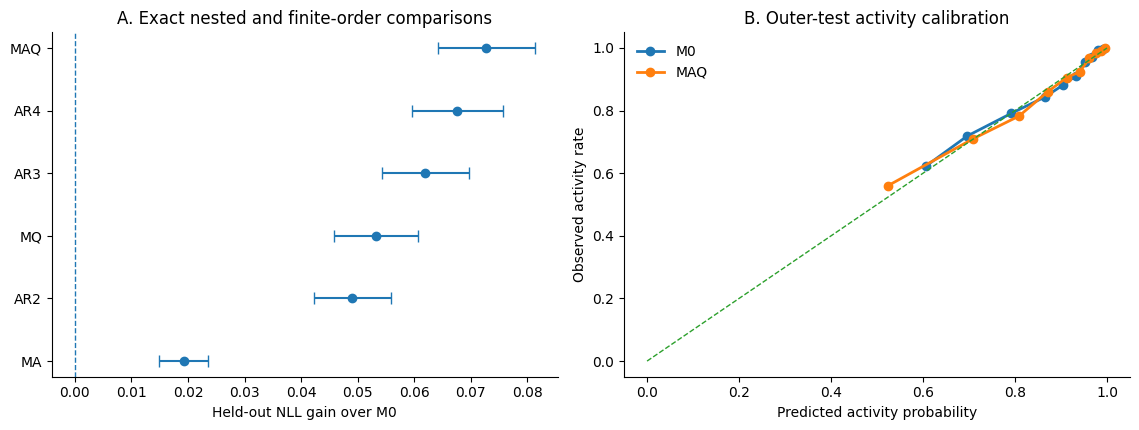

,variant,mean_nll_gain_vs_M0,ci_low,ci_high,scholars,prob_gain_positive
4,MAQ,0.072626,0.064197,0.081313,510,1.0
2,AR4,0.067552,0.059602,0.075736,510,1.0
1,AR3,0.061969,0.054319,0.069710,510,1.0
5,MQ,0.053190,0.045854,0.060585,510,1.0
0,AR2,0.048992,0.042222,0.055953,510,1.0
3,MA,0.019307,0.014928,0.023494,510,1.0


,variant,activity_log_loss,activity_brier,positive_mae_log,positive_rmse_log
5,MAQ,0.305580,0.094453,0.477777,0.595304
4,MA,0.305679,0.094485,0.513495,0.632920
2,AR4,0.307439,0.095011,0.479304,0.597496
1,AR3,0.308281,0.095361,0.483066,0.600736
0,AR2,0.311399,0.096393,0.489219,0.607571
3,M0,0.324986,0.099989,0.513495,0.632920
6,MQ,0.324986,0.099989,0.477799,0.595325


In [7]:
# Cell 6: paired scholar bootstrap, exact gains, and calibration


def scholar_nll_table(predictions):
    scholar = predictions.groupby(['repeat', 'variant', 'scholar_id'], as_index=False)['total_nll'].mean()
    return scholar.groupby(['variant', 'scholar_id'], as_index=False)['total_nll'].mean()


def paired_gain_ci(scholar_scores, comparator='M0', n_boot=N_PRED_BOOT, seed=SEED):
    pivot = scholar_scores.pivot(index='scholar_id', columns='variant', values='total_nll').dropna()
    rng = np.random.default_rng(seed)
    rows = []

    for variant in [v for v in pivot.columns if v != comparator]:
        gain = pivot[comparator] - pivot[variant]
        draws = np.empty(n_boot)
        values = gain.to_numpy()
        for b in range(n_boot):
            draws[b] = rng.choice(values, size=len(values), replace=True).mean()
        rows.append({'variant': variant, 'mean_nll_gain_vs_M0': values.mean(),
                     'ci_low': np.quantile(draws, 0.025), 'ci_high': np.quantile(draws, 0.975),
                     'scholars': len(values), 'prob_gain_positive': np.mean(draws > 0)})
    return pd.DataFrame(rows).sort_values('mean_nll_gain_vs_M0', ascending=False)


scholar_scores = scholar_nll_table(nested_predictions)
cv_gain_summary = paired_gain_ci(scholar_scores)
cv_gain_summary.to_csv(RESULT_DIR/'nested_cv_gain_summary.csv', index=False)

calibration_rows = []
for variant, d in nested_predictions.groupby('variant'):
    calibration_rows.append({
        'variant': variant,
        'activity_log_loss': log_loss(d['active'], d['p_active'], labels=[0, 1]),
        'activity_brier': brier_score_loss(d['active'], d['p_active']),
        'positive_mae_log': d.loc[d['active'].eq(1), 'residual'].abs().mean(),
        'positive_rmse_log': np.sqrt(np.mean(d.loc[d['active'].eq(1), 'residual'] ** 2))
    })
calibration_summary = pd.DataFrame(calibration_rows).sort_values('activity_log_loss')
calibration_summary.to_csv(RESULT_DIR/'out_of_sample_calibration_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
plot_gain = cv_gain_summary.sort_values('mean_nll_gain_vs_M0')
axes[0].errorbar(plot_gain['mean_nll_gain_vs_M0'], np.arange(len(plot_gain)),
                 xerr=np.vstack([np.maximum(0, plot_gain['mean_nll_gain_vs_M0'] - plot_gain['ci_low']),
                                 np.maximum(0, plot_gain['ci_high'] - plot_gain['mean_nll_gain_vs_M0'])]),
                 fmt='o', capsize=4)
axes[0].set(yticks=np.arange(len(plot_gain)), yticklabels=plot_gain['variant'], xlabel='Held-out NLL gain over M0', title='A. Exact nested and finite-order comparisons')
axes[0].axvline(0, linestyle='--', linewidth=1)

for variant in ['M0', 'MAQ']:
    d = nested_predictions[nested_predictions['variant'].eq(variant)].copy()
    d['bin'] = pd.qcut(d['p_active'], q=10, duplicates='drop')
    curve = d.groupby('bin', observed=True).agg(predicted=('p_active', 'mean'), observed=('active', 'mean'))
    axes[1].plot(curve['predicted'], curve['observed'], marker='o', linewidth=2, label=variant)
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[1].set(xlabel='Predicted activity probability', ylabel='Observed activity rate', title='B. Outer-test activity calibration')
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'nested_cv_and_calibration.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(cv_gain_summary)
display(calibration_summary)

In [8]:
# Cell 7: full-sample selections and unrestricted history estimates

full_selections = {}
full_profiles = []
full_models = {}

for variant in PRIMARY_VARIANTS:
    best, profile = tune_variant(Q_EMP, variant, SEED + 7000 + PRIMARY_VARIANTS.index(variant))
    full_selections[variant] = best
    profile['selection_scope'] = 'full_sample'
    full_profiles.append(profile)
    rho, family = float(best['rho']), str(best['family'])
    full_models[variant] = fit_model(Q_EMP, history_panel(Q_EMP, rho), variant, family, CONSTRAIN_GENERATOR)

full_profiles = pd.concat(full_profiles, ignore_index=True)
full_profiles.to_csv(RESULT_DIR/'full_sample_tuning_profiles.csv', index=False)

BEST_RHO = float(full_selections['MAQ']['rho'])
BEST_FAMILY = str(full_selections['MAQ']['family'])
HALF_LIFE = 0.0 if BEST_RHO == 0 else float(np.log(0.5) / np.log(BEST_RHO))

unrestricted_maq = fit_model(Q_EMP, history_panel(Q_EMP, BEST_RHO), 'MAQ', BEST_FAMILY, constrain_history=False)
full_parameter_table = pd.concat([
    parameter_table(full_models[variant], variant, float(full_selections[variant]['rho']), str(full_selections[variant]['family']))
    for variant in PRIMARY_VARIANTS
] + [parameter_table(unrestricted_maq, 'MAQ', BEST_RHO, BEST_FAMILY, label='MAQ unrestricted')], ignore_index=True)
full_parameter_table.to_csv(RESULT_DIR/'full_sample_parameters.csv', index=False)

print(f'Best MAQ rho: {BEST_RHO:.4f}')
print(f'Implied half-life: {HALF_LIFE:.3f} years')
print(f'Positive residual family: {BEST_FAMILY}')
display(full_parameter_table[full_parameter_table['model'].eq('MAQ unrestricted')])

Best MAQ rho: 0.6800
Implied half-life: 1.797 years
Positive residual family: normal


,model,variant,stage,equation,rho,family,n,intercept,x_prev,prev_active,...,history,x_lag2,active_lag2,lag2_available,x_lag3,active_lag3,lag3_available,x_lag4,active_lag4,lag4_available
56,MAQ unrestricted,MAQ,0,activity,0.68,normal,510,0.485508,1.111500,-0.780556,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,MAQ unrestricted,MAQ,0,positive,0.68,normal,397,0.860750,0.520505,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,MAQ unrestricted,MAQ,1-4,activity,0.68,normal,2040,-0.014359,0.939680,-0.504550,...,0.635543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,MAQ unrestricted,MAQ,1-4,positive,0.68,normal,1741,0.812490,0.382007,NaN,...,0.236320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,MAQ unrestricted,MAQ,5-7,activity,0.68,normal,1530,-0.487089,0.961042,-0.992214,...,1.290295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,MAQ unrestricted,MAQ,5-7,positive,0.68,normal,1357,0.379425,0.359356,NaN,...,0.400580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,MAQ unrestricted,MAQ,8-20,activity,0.68,normal,6120,-0.912867,1.189934,-0.878878,...,1.384850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,MAQ unrestricted,MAQ,8-20,positive,0.68,normal,5365,0.012937,0.434403,NaN,...,0.488716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Cell 7B: normalized memory versus additive excitation stock


def tune_history_kind(q, kind, seed):
    splits = kfold_indices(len(q), min(INNER_SPLITS, len(q)), seed)
    rows = []
    for family in RESIDUAL_FAMILIES:
        for rho in RHO_GRID:
            history = history_panel(q, rho, kind=kind)
            scores = []
            for train_idx, test_idx in splits:
                model = fit_model(q[train_idx], history[train_idx], 'MAQ', family, CONSTRAIN_GENERATOR)
                scores.append(score_model(model, q[test_idx], history[test_idx]))
            rows.append({'history_kind': kind, 'family': family, 'rho': float(rho), 'mean_nll': np.mean(scores)})
    profile = pd.DataFrame(rows)
    return profile.loc[profile['mean_nll'].idxmin()].to_dict(), profile


state_form_rows = []
state_form_profiles = []
for repeat in range(OUTER_REPEATS):
    for fold, (train_idx, test_idx) in enumerate(kfold_indices(N_EMP, OUTER_SPLITS, SEED + 15000 + repeat)):
        for kind in ['normalized', 'additive']:
            best, profile = tune_history_kind(Q_EMP[train_idx], kind, SEED + 15100 + 100 * repeat + 10 * fold + (kind == 'additive'))
            rho, family = float(best['rho']), str(best['family'])
            h_train = history_panel(Q_EMP[train_idx], rho, kind=kind)
            h_test = history_panel(Q_EMP[test_idx], rho, kind=kind)
            model = fit_model(Q_EMP[train_idx], h_train, 'MAQ', family, CONSTRAIN_GENERATOR)
            state_form_rows.append({'repeat': repeat, 'fold': fold, 'history_kind': kind, 'rho': rho, 'family': family,
                                    'test_nll': score_model(model, Q_EMP[test_idx], h_test)})
            profile['repeat'] = repeat
            profile['fold'] = fold
            state_form_profiles.append(profile)

state_form_cv = pd.DataFrame(state_form_rows)
state_form_profile = pd.concat(state_form_profiles, ignore_index=True)
state_form_summary = state_form_cv.groupby('history_kind').agg(mean_test_nll=('test_nll', 'mean'),
                                                               se_test_nll=('test_nll', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                                                               median_rho=('rho', 'median')).reset_index()
state_form_cv.to_csv(RESULT_DIR/'history_state_form_cv.csv', index=False)
state_form_profile.to_csv(RESULT_DIR/'history_state_form_tuning.csv', index=False)
state_form_summary.to_csv(RESULT_DIR/'history_state_form_summary.csv', index=False)

display(state_form_summary)

,history_kind,mean_test_nll,se_test_nll,median_rho
0,additive,1.090072,0.003389,0.62
1,normalized,1.087012,0.003310,0.68


In [10]:
# Cell 8: full-pipeline scholar bootstrap with rho reselected each time

rng = np.random.default_rng(SEED + 8000)
bootstrap_parameters = []
bootstrap_metrics = []

for b in range(N_PIPE_BOOT):
    sampled = rng.integers(0, N_EMP, size=N_EMP)
    q_boot = Q_EMP[sampled]
    best, _ = tune_variant(q_boot, 'MAQ', SEED + 8100 + b)
    rho, family = float(best['rho']), str(best['family'])
    h_boot = history_panel(q_boot, rho)
    model = fit_model(q_boot, h_boot, 'MAQ', family, constrain_history=False)
    table = parameter_table(model, 'MAQ', rho, family, label='bootstrap unrestricted')
    table['bootstrap'] = b
    bootstrap_parameters.append(table)

    q_sim = simulate_model(model, rho, N_EMP, SEED + 9000 + b, init_pool=q_boot[:, 0])
    bootstrap_metrics.append({'bootstrap': b, 'rho': rho,
                              'half_life': 0.0 if rho == 0 else np.log(0.5) / np.log(rho),
                              **generative_metrics(q_boot, q_sim)})

    if (b + 1) % max(1, N_PIPE_BOOT // 10) == 0:
        print(f'pipeline bootstrap {b + 1}/{N_PIPE_BOOT}')

bootstrap_parameters = pd.concat(bootstrap_parameters, ignore_index=True)
bootstrap_metrics = pd.DataFrame(bootstrap_metrics)
bootstrap_parameters.to_csv(RESULT_DIR/'full_pipeline_bootstrap_parameters.csv', index=False)
bootstrap_metrics.to_csv(RESULT_DIR/'full_pipeline_bootstrap_metrics.csv', index=False)

history_bootstrap_ci = (bootstrap_parameters[
    bootstrap_parameters['history'].notna() & ~bootstrap_parameters['stage'].eq('0')
].groupby(['stage', 'equation'])['history'].quantile([0.025, 0.5, 0.975]).unstack().reset_index().rename(columns={0.025: 'low', 0.5: 'median', 0.975: 'high'}))
history_bootstrap_ci['excludes_zero'] = (history_bootstrap_ci['low'] > 0) | (history_bootstrap_ci['high'] < 0)
history_bootstrap_ci.to_csv(RESULT_DIR/'history_full_pipeline_bootstrap_ci.csv', index=False)

display(history_bootstrap_ci)
display(bootstrap_metrics.quantile([0.025, 0.5, 0.975], numeric_only=True))

pipeline bootstrap 50/500
pipeline bootstrap 100/500
pipeline bootstrap 150/500
pipeline bootstrap 200/500
pipeline bootstrap 250/500
pipeline bootstrap 300/500
pipeline bootstrap 350/500
pipeline bootstrap 400/500
pipeline bootstrap 450/500
pipeline bootstrap 500/500


,stage,equation,low,median,high,excludes_zero
0,1-4,activity,0.452641,0.629142,0.815465,True
1,1-4,positive,0.190201,0.237591,0.279106,True
2,5-7,activity,1.009669,1.301029,1.594463,True
3,5-7,positive,0.337347,0.399526,0.463501,True
4,8-20,activity,1.219850,1.379813,1.565205,True
5,8-20,positive,0.449791,0.488065,0.526754,True


,bootstrap,rho,half_life,terminal_rank_emp,terminal_rank_sim,terminal_rank_abs_error,rank_curve_rmse,zero_count_ks,cumulative_ks,year_max_ks,increment_qq_emp,increment_qq_sim
0.025,12.475,0.62,1.449990,0.097347,0.068770,0.001690,0.042071,0.023529,0.045098,0.029412,0.997423,0.941855
0.500,249.500,0.68,1.797290,0.183486,0.160197,0.046569,0.063616,0.047059,0.072549,0.056863,0.998078,0.979741
0.975,486.525,0.72,2.110011,0.271923,0.258141,0.142287,0.104143,0.087304,0.116716,0.097108,0.998535,0.990971


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/x7/63pdtssn3dz4flvgpf_j1xhr0000gn/T/ipykernel_65012/62253457.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=['M0', 'MAQ'], showfliers=False)
/var/folders/x7/63pdtssn3dz4flvgpf_j1xhr0000gn/T/ipykernel_65012/62253457.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=['M0', 'MAQ'], showfliers=False)
/var/folders/x7/63pdtssn3dz4flvgpf_j1xhr0000gn/T/ipykernel_65012/62253457.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has be

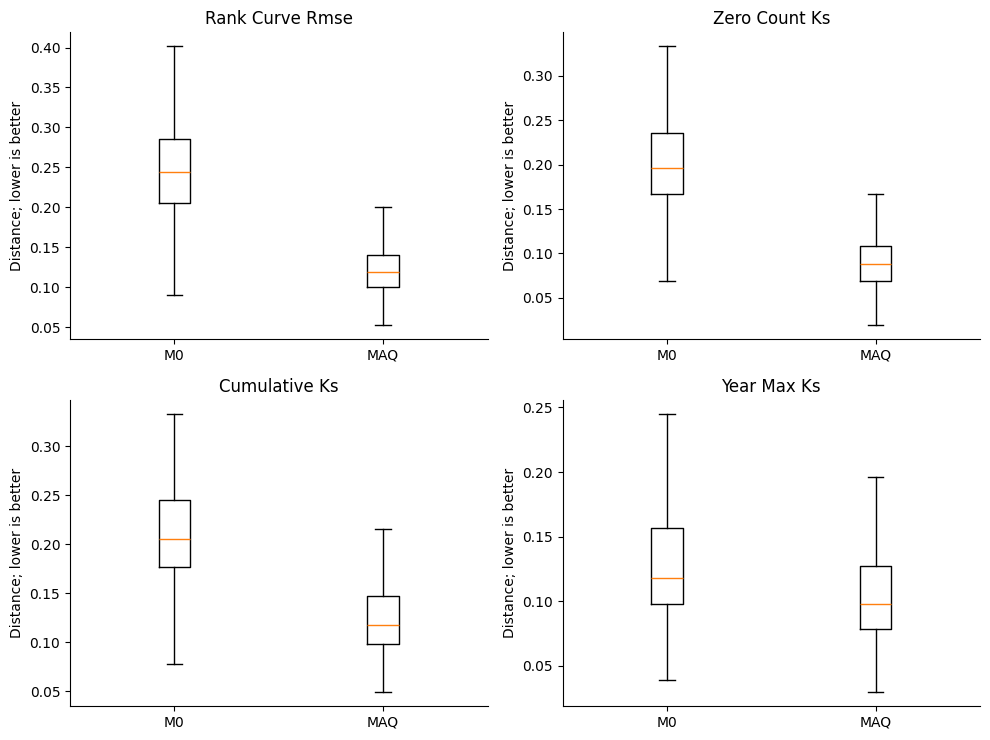

,variant,terminal_rank_abs_error,rank_curve_rmse,zero_count_ks,cumulative_ks,year_max_ks,increment_qq_sim
0,M0,0.200348,0.246026,0.202275,0.208043,0.126549,0.966668
1,MAQ,0.109441,0.123200,0.091247,0.123557,0.107976,0.976170


In [11]:
# Cell 9: held-out generative validation conditional on each test scholar's q0

generative_rows = []

for repeat in range(OUTER_REPEATS):
    outer = kfold_indices(N_EMP, OUTER_SPLITS, SEED + 100 * repeat)
    for fold, (train_idx, test_idx) in enumerate(outer):
        q_train, q_test = Q_EMP[train_idx], Q_EMP[test_idx]

        for variant in ['M0', 'MAQ']:
            selected = nested_folds[(nested_folds['repeat'].eq(repeat)) & (nested_folds['fold'].eq(fold)) & (nested_folds['variant'].eq(variant))].iloc[0]
            rho, family = float(selected['rho']), str(selected['family'])
            model = fit_model(q_train, history_panel(q_train, rho), variant, family, CONSTRAIN_GENERATOR)

            for rep in range(N_GENERATIVE_REPS):
                q_sim = simulate_model(model, rho, len(test_idx), SEED + 100000 * repeat + 1000 * fold + 100 * PRIMARY_VARIANTS.index(variant) + rep,
                                       q0=q_test[:, 0], init_pool=q_train[:, 0])
                generative_rows.append({'repeat': repeat, 'fold': fold, 'rep': rep, 'variant': variant, **generative_metrics(q_test, q_sim)})

heldout_generative = pd.DataFrame(generative_rows)
heldout_generative.to_csv(RESULT_DIR/'heldout_generative_metrics.csv', index=False)

generative_summary = heldout_generative.groupby('variant').agg(
    terminal_rank_abs_error=('terminal_rank_abs_error', 'mean'),
    rank_curve_rmse=('rank_curve_rmse', 'mean'),
    zero_count_ks=('zero_count_ks', 'mean'),
    cumulative_ks=('cumulative_ks', 'mean'),
    year_max_ks=('year_max_ks', 'mean'),
    increment_qq_sim=('increment_qq_sim', 'mean')
).reset_index()
generative_summary.to_csv(RESULT_DIR/'heldout_generative_summary.csv', index=False)

metrics = ['rank_curve_rmse', 'zero_count_ks', 'cumulative_ks', 'year_max_ks']
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, metric in zip(axes.ravel(), metrics):
    values = [heldout_generative.loc[heldout_generative['variant'].eq(v), metric] for v in ['M0', 'MAQ']]
    ax.boxplot(values, labels=['M0', 'MAQ'], showfliers=False)
    ax.set(title=metric.replace('_', ' ').title(), ylabel='Distance; lower is better')
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'heldout_generative_validation.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(generative_summary)

## Is exponential decay the right compression?

The next section compares a current-state model, the one-dimensional exponential state, and unrestricted distributed lags on the same late-career transitions. It also tests whether the unrestricted lag coefficients follow a geometric decay.

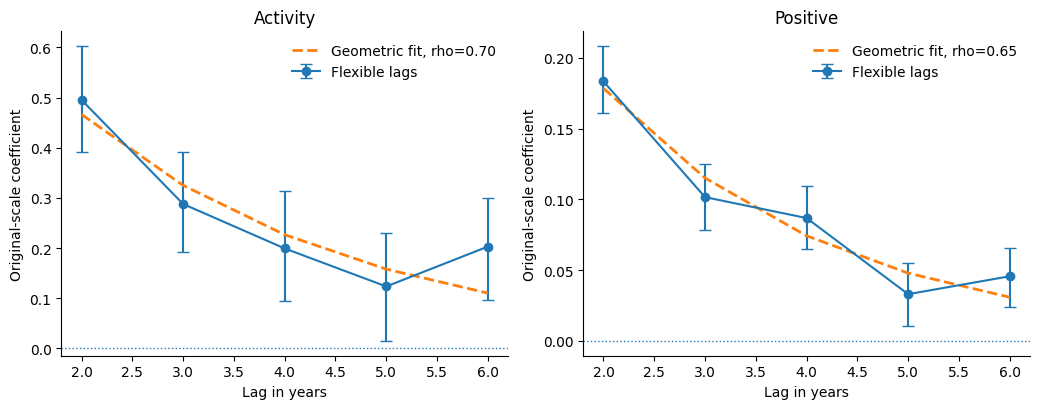

,model,activity_log_loss,activity_brier,positive_mae_log,positive_rmse_log
0,Current state,0.304110,0.093029,0.514499,0.636948
1,Exponential history,0.280792,0.086300,0.471977,0.591370
2,Flexible lags,0.281868,0.086635,0.472611,0.592307


,equation,geometric_rho,geometric_half_life
0,activity,0.697138,1.921288
1,positive,0.645214,1.581900


In [12]:
# Cell 10: flexible distributed lags versus the exponential state

MAX_LAG = 6
H_BEST = history_panel(Q_EMP, BEST_RHO)
lag_rows = []

for target_year in range(MAX_LAG, Y + 1):
    q_now = Q_EMP[:, target_year]
    q_prev = Q_EMP[:, target_year - 1]
    d = pd.DataFrame({
        'scholar_id': EMP_IDS,
        'target_year': target_year,
        'active': (q_now > 0).astype(int),
        'log_q': np.where(q_now > 0, np.log(np.maximum(q_now, 1e-12)), np.nan),
        'x_prev': np.log1p(q_prev),
        'prev_active': (q_prev > 0).astype(int),
        'restart': (q_prev <= 0).astype(int),
        'history': H_BEST[:, target_year]
    })
    for lag in range(2, MAX_LAG + 1):
        d[f'lag{lag}'] = np.log1p(Q_EMP[:, target_year - lag])
    lag_rows.append(d)

lag_data = pd.concat(lag_rows, ignore_index=True)
year_dummies = pd.get_dummies(lag_data['target_year'], prefix='year', dtype=float)
lag_data = pd.concat([lag_data, year_dummies], axis=1)
year_features = list(year_dummies.columns)
lag_features = [f'lag{lag}' for lag in range(2, MAX_LAG + 1)]

feature_sets = {
    'Current state': ['x_prev', 'prev_active', 'restart'] + year_features,
    'Exponential history': ['x_prev', 'prev_active', 'restart', 'history'] + year_features,
    'Flexible lags': ['x_prev', 'prev_active', 'restart'] + lag_features + year_features
}


def grouped_prediction_scores(data, features):
    groups = data['scholar_id'].to_numpy()
    splits = list(GroupKFold(n_splits=OUTER_SPLITS).split(data, groups=groups))
    p = np.empty(len(data))

    for train_idx, test_idx in splits:
        model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000))
        model.fit(data.iloc[train_idx][features], data.iloc[train_idx]['active'])
        p[test_idx] = model.predict_proba(data.iloc[test_idx][features])[:, 1]

    positive = data[data['active'].eq(1)].copy()
    groups_pos = positive['scholar_id'].to_numpy()
    pred = np.empty(len(positive))
    for train_idx, test_idx in GroupKFold(n_splits=OUTER_SPLITS).split(positive, groups=groups_pos):
        model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        model.fit(positive.iloc[train_idx][features], positive.iloc[train_idx]['log_q'])
        pred[test_idx] = model.predict(positive.iloc[test_idx][features])

    return {
        'activity_log_loss': log_loss(data['active'], p, labels=[0, 1]),
        'activity_brier': brier_score_loss(data['active'], p),
        'positive_mae_log': np.mean(np.abs(positive['log_q'].to_numpy() - pred)),
        'positive_rmse_log': np.sqrt(np.mean((positive['log_q'].to_numpy() - pred) ** 2))
    }


lag_cv = pd.DataFrame([{'model': name, **grouped_prediction_scores(lag_data, features)} for name, features in feature_sets.items()])
lag_cv.to_csv(RESULT_DIR/'distributed_lag_cv.csv', index=False)


def fit_lag_coefficients(data):
    features = feature_sets['Flexible lags']
    activity_model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000)).fit(data[features], data['active'])
    positive = data[data['active'].eq(1)]
    positive_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(positive[features], positive['log_q'])

    act_scale = activity_model.named_steps['standardscaler'].scale_
    pos_scale = positive_model.named_steps['standardscaler'].scale_
    act_coef = activity_model.named_steps['logisticregression'].coef_[0] / act_scale
    pos_coef = positive_model.named_steps['ridge'].coef_ / pos_scale
    indices = [features.index(name) for name in lag_features]
    return act_coef[indices], pos_coef[indices]


def fit_geometric_kernel(coefficients):
    coefficients = np.asarray(coefficients)
    lags = np.arange(2, MAX_LAG + 1)
    result = minimize(lambda p: np.sum((coefficients - p[0] * p[1] ** (lags - 2)) ** 2),
                      x0=np.array([max(coefficients[0], 1e-4), 0.6]), bounds=[(0, None), (0, 0.999)])
    return result.x[0], result.x[1]


act_coef, pos_coef = fit_lag_coefficients(lag_data)
act_c, act_rho = fit_geometric_kernel(act_coef)
pos_c, pos_rho = fit_geometric_kernel(pos_coef)

rng = np.random.default_rng(SEED + 11000)
lag_boot = []
unique_ids = pd.unique(lag_data['scholar_id'])
for b in range(N_LAG_BOOT):
    sampled_ids = rng.choice(unique_ids, size=len(unique_ids), replace=True)
    pieces = []
    for copy, scholar_id in enumerate(sampled_ids):
        d = lag_data[lag_data['scholar_id'].eq(scholar_id)].copy()
        d['scholar_id'] = copy
        pieces.append(d)
    sample = pd.concat(pieces, ignore_index=True)
    a, p = fit_lag_coefficients(sample)
    for lag, a_value, p_value in zip(range(2, MAX_LAG + 1), a, p):
        lag_boot.append({'bootstrap': b, 'lag': lag, 'activity': a_value, 'positive': p_value})

lag_boot = pd.DataFrame(lag_boot)
lag_ci = lag_boot.groupby('lag')[['activity', 'positive']].quantile([0.025, 0.5, 0.975]).unstack()
lag_ci.columns = [f'{equation}_{quantile}' for equation, quantile in lag_ci.columns]
lag_ci = lag_ci.reset_index()
lag_ci.to_csv(RESULT_DIR/'distributed_lag_bootstrap_ci.csv', index=False)

lags = np.arange(2, MAX_LAG + 1)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=True)
for ax, equation, coef, c, rho in [
    (axes[0], 'activity', act_coef, act_c, act_rho),
    (axes[1], 'positive', pos_coef, pos_c, pos_rho)
]:
    low = lag_ci[f'{equation}_0.025']
    high = lag_ci[f'{equation}_0.975']
    ax.errorbar(lags, coef, yerr=np.vstack([np.maximum(0, coef - low), np.maximum(0, high - coef)]), marker='o', capsize=4, label='Flexible lags')
    ax.plot(lags, c * rho ** (lags - 2), linestyle='--', linewidth=2, label=f'Geometric fit, rho={rho:.2f}')
    ax.axhline(0, linewidth=1, linestyle=':')
    ax.set(title=equation.title(), xlabel='Lag in years', ylabel='Original-scale coefficient')
    ax.legend(frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'distributed_lag_kernel.png', dpi=DPI, bbox_inches='tight')
plt.show()

kernel_summary = pd.DataFrame({
    'equation': ['activity', 'positive'],
    'geometric_rho': [act_rho, pos_rho],
    'geometric_half_life': [np.log(0.5) / np.log(act_rho) if 0 < act_rho < 1 else np.nan,
                            np.log(0.5) / np.log(pos_rho) if 0 < pos_rho < 1 else np.nan]
})
kernel_summary.to_csv(RESULT_DIR/'distributed_lag_kernel_summary.csv', index=False)

display(lag_cv)
display(kernel_summary)

In [13]:
# Cell 11: how much of all predictable history is captured by H_t?

PREDICTION_HORIZONS = [1, 2, 5]


def run_lengths(active):
    active_run = np.zeros(len(active), dtype=int)
    zero_run = np.zeros(len(active), dtype=int)
    a = z = 0
    for t, value in enumerate(active):
        a = a + 1 if value else 0
        z = z + 1 if not value else 0
        active_run[t], zero_run[t] = a, z
    return active_run, zero_run


def prediction_data(q, ids, rho):
    h = history_panel(q, rho)
    pieces = []
    for row, (scholar_id, trajectory) in enumerate(zip(ids, q)):
        logged = np.log(trajectory + EPS)
        active = trajectory > 0
        active_run, zero_run = run_lengths(active)
        d = pd.DataFrame({
            'scholar_id': scholar_id,
            'year': np.arange(len(trajectory)),
            'z': logged,
            'active': active.astype(int),
            'history': h[row],
            'dz1': np.r_[np.nan, np.diff(logged)],
            'slope3': np.r_[np.nan, np.nan, (logged[2:] - logged[:-2]) / 2],
            'sd3': pd.Series(logged).rolling(3, min_periods=2).std(ddof=0).to_numpy(),
            'log_cum_q': np.log1p(np.cumsum(trajectory)),
            'drawdown': np.log1p(np.maximum.accumulate(trajectory)) - np.log1p(trajectory),
            'active_run': active_run,
            'zero_run': zero_run
        })
        pieces.append(d)
    data = pd.concat(pieces, ignore_index=True)
    grouped = data.groupby('scholar_id', sort=False)
    for horizon in PREDICTION_HORIZONS:
        data[f'z_f{horizon}'] = grouped['z'].shift(-horizon)
    return data


pred_data = prediction_data(Q_EMP, EMP_IDS, BEST_RHO)
BASE = ['year', 'z', 'active']
EXP = BASE + ['history']
FULL = BASE + ['dz1', 'slope3', 'sd3', 'log_cum_q', 'drawdown', 'active_run', 'zero_run']
PREDICTOR_SETS = {'Current state': BASE, 'Exponential state': EXP, 'All history features': FULL}


def prediction_model():
    return make_pipeline(SimpleImputer(strategy='median'), HistGradientBoostingRegressor(
        learning_rate=0.05, max_depth=3, max_iter=300, l2_regularization=1.0, random_state=SEED))


def grouped_oof_predictions(data, features, target):
    use = data.dropna(subset=[target]).copy()
    groups = use['scholar_id'].to_numpy()
    y = use[target].to_numpy()
    pred = np.empty(len(use))
    for train_idx, test_idx in GroupKFold(n_splits=OUTER_SPLITS).split(use, groups=groups):
        model = prediction_model().fit(use.iloc[train_idx][features], y[train_idx])
        pred[test_idx] = model.predict(use.iloc[test_idx][features])
    return use, y, pred


compression_rows = []
compression_errors = []
for horizon in PREDICTION_HORIZONS:
    target = f'z_f{horizon}'
    for label, features in PREDICTOR_SETS.items():
        use, y, pred = grouped_oof_predictions(pred_data, features, target)
        errors = np.abs(y - pred)
        compression_rows.append({'horizon': horizon, 'model': label, 'mae': errors.mean(), 'spearman': stats.spearmanr(y, pred).statistic})
        compression_errors.append(pd.DataFrame({'scholar_id': use['scholar_id'].to_numpy(), 'horizon': horizon, 'model': label, 'absolute_error': errors}))

compression_results = pd.DataFrame(compression_rows)
compression_error_rows = pd.concat(compression_errors, ignore_index=True)
pivot = compression_results.pivot(index='horizon', columns='model', values='mae')
compression_fraction = ((pivot['Current state'] - pivot['Exponential state']) /
                        (pivot['Current state'] - pivot['All history features'])).rename('fraction_of_history_gain_captured').reset_index()
compression_results.to_csv(RESULT_DIR/'history_compression_prediction.csv', index=False)
compression_fraction.to_csv(RESULT_DIR/'history_compression_fraction.csv', index=False)

display(compression_results)
display(compression_fraction)

,horizon,model,mae,spearman
0,1,Current state,0.703194,0.602952
1,1,Exponential state,0.668581,0.646647
2,1,All history features,0.655191,0.668387
3,2,Current state,0.711080,0.580812
4,2,Exponential state,0.682378,0.621209
5,2,All history features,0.671662,0.635611
6,5,Current state,0.753707,0.482606
7,5,Exponential state,0.729775,0.534016
8,5,All history features,0.724042,0.543767


,horizon,fraction_of_history_gain_captured
0,1,0.721052
1,2,0.728151
2,5,0.806729


## Temporal and ownership falsification

The real history state should outperform histories assigned to the wrong scholar. A comparable reverse-time effect would instead suggest smooth latent trajectories or stable heterogeneity.

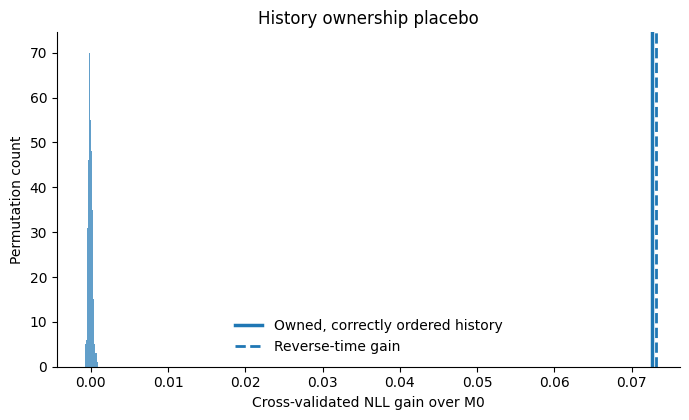

,real_history_gain,permuted_mean_gain,permutation_p,reverse_time_gain,reverse_time_rho
0,0.072597,-0.000081,0.001996,0.073157,0.7


In [14]:
# Cell 12: within-state history permutation and reverse-time placebo


def permute_history(q, history, seed):
    rng = np.random.default_rng(seed)
    permuted = history.copy()

    for target_year in range(2, q.shape[1]):
        q_prev = q[:, target_year - 1]
        active = q_prev > 0
        bins = pd.Series(np.log1p(q_prev)).groupby(active).transform(
            lambda s: pd.qcut(s.rank(method='first'), q=min(5, len(s)), labels=False, duplicates='drop'))
        group = pd.DataFrame({'active': active, 'bin': bins}).fillna(-1)
        for _, idx in group.groupby(['active', 'bin']).groups.items():
            idx = np.asarray(list(idx), dtype=int)
            if len(idx) > 1:
                permuted[idx, target_year] = rng.permutation(permuted[idx, target_year])
    return permuted


def cv_gain_with_history(q, history, seed, family=BEST_FAMILY):
    gains = []
    for train_idx, test_idx in kfold_indices(len(q), OUTER_SPLITS, seed):
        m0 = fit_model(q[train_idx], np.zeros_like(q[train_idx]), 'M0', family, CONSTRAIN_GENERATOR)
        maq = fit_model(q[train_idx], history[train_idx], 'MAQ', family, CONSTRAIN_GENERATOR)
        gains.append(score_model(m0, q[test_idx], np.zeros_like(q[test_idx])) - score_model(maq, q[test_idx], history[test_idx]))
    return float(np.mean(gains))


real_history = history_panel(Q_EMP, BEST_RHO)
real_placebo_gain = cv_gain_with_history(Q_EMP, real_history, SEED + 12000)
permuted_gains = []
for b in range(N_PLACEBO):
    h_perm = permute_history(Q_EMP, real_history, SEED + 12100 + b)
    permuted_gains.append(cv_gain_with_history(Q_EMP, h_perm, SEED + 12200 + b))

q_reverse = Q_EMP[:, ::-1]
reverse_m0, _ = tune_variant(q_reverse, 'M0', SEED + 12300)
reverse_maq, _ = tune_variant(q_reverse, 'MAQ', SEED + 12400)
reverse_gain = reverse_m0['mean_nll'] - reverse_maq['mean_nll']

placebo_summary = pd.DataFrame([{
    'real_history_gain': real_placebo_gain,
    'permuted_mean_gain': np.mean(permuted_gains),
    'permutation_p': (1 + np.sum(np.asarray(permuted_gains) >= real_placebo_gain)) / (N_PLACEBO + 1),
    'reverse_time_gain': reverse_gain,
    'reverse_time_rho': reverse_maq['rho']
}])
placebo_draws = pd.DataFrame({'permuted_gain': permuted_gains})
placebo_summary.to_csv(RESULT_DIR/'history_placebo_summary.csv', index=False)
placebo_draws.to_csv(RESULT_DIR/'history_placebo_draws.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.hist(permuted_gains, bins=20, alpha=0.7)
ax.axvline(real_placebo_gain, linewidth=2.5, label='Owned, correctly ordered history')
ax.axvline(reverse_gain, linewidth=2, linestyle='--', label='Reverse-time gain')
ax.set(title='History ownership placebo', xlabel='Cross-validated NLL gain over M0', ylabel='Permutation count')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'history_placebo.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(placebo_summary)

Fixed-rho adversarial validation: 200 remaining of 200; 4 workers; 5-fold CV; 25 rho-recovery replicates.
Empirical fixed-rho MAQ gain: 0.072703 at rho=0.6800
completed 8/200 replicates; elapsed 0.7 min
completed 16/200 replicates; elapsed 1.3 min
completed 24/200 replicates; elapsed 2.0 min
completed 32/200 replicates; elapsed 2.2 min
completed 40/200 replicates; elapsed 2.4 min
completed 48/200 replicates; elapsed 2.5 min
completed 56/200 replicates; elapsed 2.7 min
completed 64/200 replicates; elapsed 2.8 min
completed 72/200 replicates; elapsed 3.0 min
completed 80/200 replicates; elapsed 3.1 min
completed 88/200 replicates; elapsed 3.3 min
completed 96/200 replicates; elapsed 3.4 min
completed 104/200 replicates; elapsed 3.6 min
completed 112/200 replicates; elapsed 3.7 min
completed 120/200 replicates; elapsed 3.9 min
completed 128/200 replicates; elapsed 4.0 min
completed 136/200 replicates; elapsed 4.1 min
completed 144/200 replicates; elapsed 4.3 min
completed 152/200 replicat

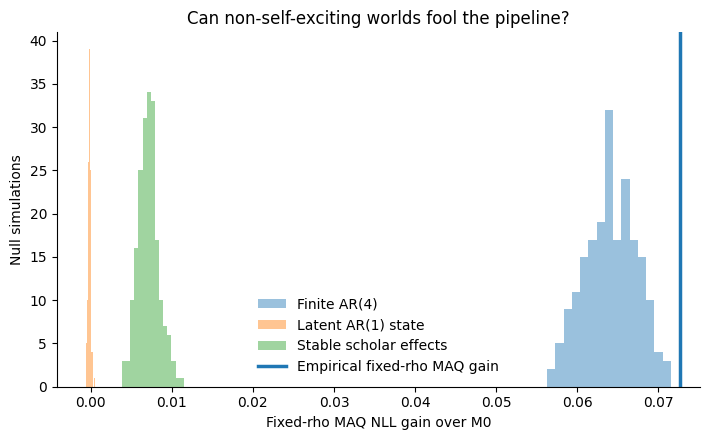

,null,mean_false_gain,q95_false_gain,false_gain_p,evaluation_rho,mean_terminal_rank
0,Finite AR(4),0.064103,0.069222,0.004975,0.68,0.072953
1,Latent AR(1) state,-0.000174,0.000134,0.004975,0.68,0.001411
2,Stable scholar effects,0.007121,0.009754,0.004975,0.68,0.185488


,true_rho,n_gain_reps,n_rho_recovery_reps,median_recovered_rho,rho_mae,mean_recovered_gain,power_gain_positive
0,0.68,200,25,0.68,0.00608,0.073014,1.0


In [16]:
# Cell 13: adversarial nulls and positive model recovery
# Fast version: fixed-rho null test, paired CV, parallel batches, and checkpoints

import os
import time
from joblib import Parallel, delayed, parallel_backend


base_model = full_models['M0']
base_details = score_model_details(
    base_model,
    Q_EMP,
    np.zeros_like(Q_EMP),
    EMP_IDS
)


# Estimate stable scholar effects under the no-history model

scholar_effect_rows = []

for scholar_id, d in base_details.groupby('scholar_id'):
    numerator = np.sum(d['active'] - d['p_active'])
    denominator = np.sum(
        d['p_active'] * (1 - d['p_active'])
    ) + 1.0

    u_activity = np.clip(
        numerator / denominator,
        -3,
        3
    )

    u_positive = d.loc[
        d['active'].eq(1),
        'residual'
    ].mean()

    scholar_effect_rows.append({
        'scholar_id': scholar_id,
        'u_activity': u_activity,
        'u_positive': u_positive
    })


scholar_effects = (
    pd.DataFrame(scholar_effect_rows)
    .fillna(0.0)
    .set_index('scholar_id')
    .reindex(EMP_IDS)
)

scholar_effects[
    ['u_activity', 'u_positive']
] -= scholar_effects[
    ['u_activity', 'u_positive']
].mean()

effect_matrix = scholar_effects[
    ['u_activity', 'u_positive']
].to_numpy()


# Estimate residual persistence for the latent-state null

positive_base = base_details.loc[
    base_details['active'].eq(1),
    ['scholar_id', 'target_year', 'residual']
]

lagged_base = positive_base.merge(
    positive_base,
    on='scholar_id',
    suffixes=('_t', '_lag')
)

lagged_base = lagged_base[
    lagged_base['target_year_t'].eq(
        lagged_base['target_year_lag'] + 1
    )
]

if len(lagged_base) < 3:
    latent_phi = 0.0
else:
    latent_phi = float(np.clip(
        stats.pearsonr(
            lagged_base['residual_t'],
            lagged_base['residual_lag']
        ).statistic,
        0,
        0.95
    ))

latent_activity_loading = max(
    float(
        scholar_effects['u_activity'].std(ddof=0)
    ),
    1e-6
)

latent_positive_loading = max(
    float(
        scholar_effects['u_positive'].std(ddof=0)
    ),
    1e-6
)


def paired_fixed_rho_gain(
    q,
    rho,
    seed,
    n_splits=None
):
    """
    Compare M0 and MAQ using identical scholar folds and a fixed rho.

    This is the main adversarial-null statistic. Holding rho fixed at the
    empirically selected value removes the expensive rho-tuning loop and asks
    whether that particular empirical memory kernel also creates apparent
    gains in non-self-exciting worlds.
    """

    n_splits = min(
        INNER_SPLITS if n_splits is None else n_splits,
        len(q)
    )

    splits = kfold_indices(
        len(q),
        n_splits,
        seed
    )

    zero_history = np.zeros_like(q)
    maq_history = history_panel(q, rho)

    rows = []

    for fold, (train_idx, test_idx) in enumerate(splits):
        m0 = fit_model(
            q[train_idx],
            zero_history[train_idx],
            'M0',
            BEST_FAMILY,
            CONSTRAIN_GENERATOR
        )

        maq = fit_model(
            q[train_idx],
            maq_history[train_idx],
            'MAQ',
            BEST_FAMILY,
            CONSTRAIN_GENERATOR
        )

        m0_nll = score_model(
            m0,
            q[test_idx],
            zero_history[test_idx]
        )

        maq_nll = score_model(
            maq,
            q[test_idx],
            maq_history[test_idx]
        )

        rows.append({
            'fold': fold,
            'm0_nll': m0_nll,
            'maq_nll': maq_nll,
            'gain': m0_nll - maq_nll
        })

    rows = pd.DataFrame(rows)

    return {
        'gain': float(rows['gain'].mean()),
        'rho': float(rho),
        'm0_nll': float(rows['m0_nll'].mean()),
        'maq_nll': float(rows['maq_nll'].mean())
    }


def selected_rho_gain(
    q,
    seed,
    rho_grid,
    n_splits=None
):
    """
    Recover rho in positive simulations.

    M0 is fitted once per fold rather than once for every rho candidate.
    """

    n_splits = min(
        INNER_SPLITS if n_splits is None else n_splits,
        len(q)
    )

    splits = kfold_indices(
        len(q),
        n_splits,
        seed
    )

    zero_history = np.zeros_like(q)
    m0_scores = []

    for train_idx, test_idx in splits:
        m0 = fit_model(
            q[train_idx],
            zero_history[train_idx],
            'M0',
            BEST_FAMILY,
            CONSTRAIN_GENERATOR
        )

        m0_scores.append(
            score_model(
                m0,
                q[test_idx],
                zero_history[test_idx]
            )
        )

    profile = []

    for rho in rho_grid:
        history = history_panel(q, rho)
        scores = []

        for train_idx, test_idx in splits:
            maq = fit_model(
                q[train_idx],
                history[train_idx],
                'MAQ',
                BEST_FAMILY,
                CONSTRAIN_GENERATOR
            )

            scores.append(
                score_model(
                    maq,
                    q[test_idx],
                    history[test_idx]
                )
            )

        profile.append({
            'rho': float(rho),
            'maq_nll': float(np.mean(scores))
        })

    profile = pd.DataFrame(profile)
    best = profile.loc[
        profile['maq_nll'].idxmin()
    ]

    return {
        'gain': float(
            np.mean(m0_scores) - best['maq_nll']
        ),
        'rho': float(best['rho']),
        'm0_nll': float(np.mean(m0_scores)),
        'maq_nll': float(best['maq_nll'])
    }


def simulate_latent_state_null(
    model,
    n_sim,
    seed,
    q0
):
    rng = np.random.default_rng(seed)

    simulated = np.zeros(
        (n_sim, Y + 1),
        dtype=float
    )

    simulated[:, 0] = q0

    state = rng.normal(size=n_sim)

    innovation_sd = np.sqrt(
        max(
            1 - latent_phi ** 2,
            1e-8
        )
    )

    for target_year in range(1, Y + 1):
        values = simulation_values(
            simulated,
            target_year,
            np.zeros(n_sim)
        )

        stage = transition_stage(
            target_year - 1
        )

        activity = model[stage]['activity']

        eta = (
            array_design(
                values,
                activity
            ) @ activity['coef']
            + latent_activity_loading * state
        )

        active = (
            rng.random(n_sim)
            < expit(np.clip(eta, -35, 35))
        )

        if active.any():
            positive = model[stage]['positive']

            active_values = {
                name: np.asarray(value)[active]
                for name, value in values.items()
            }

            mu = (
                array_design(
                    active_values,
                    positive
                ) @ positive['coef']
                + latent_positive_loading
                * state[active]
            )

            simulated[
                active,
                target_year
            ] = np.exp(np.clip(
                mu + draw_residuals(
                    positive,
                    active.sum(),
                    rng
                ),
                -30,
                30
            ))

        state = (
            latent_phi * state
            + rng.normal(
                0,
                innovation_sd,
                size=n_sim
            )
        )

    return simulated


# Computational controls

NULL_CV_SPLITS = min(
    INNER_SPLITS,
    5
)

# Full rho recovery is only needed for a subset of positive simulations.
N_RHO_RECOVERY = min(
    N_NULL,
    25 if PAPER_RUN else 5
)

RECOVERY_RHO_GRID = np.unique(np.r_[
    np.linspace(
        0.0,
        0.98,
        21 if PAPER_RUN else 9
    ),
    BEST_RHO
])

# Four processes is usually a good ceiling on a laptop.
N_NULL_JOBS = min(
    4,
    max(
        1,
        (os.cpu_count() or 2) - 1
    )
)

NULL_BATCH_SIZE = max(
    N_NULL_JOBS,
    2 * N_NULL_JOBS
)


ar4_model = full_models['AR4']


# Compute the empirical reference using the identical fixed-rho test.
# Do not compare a fixed-rho null statistic with the differently selected
# nested-CV statistic.

empirical_fixed = paired_fixed_rho_gain(
    Q_EMP,
    BEST_RHO,
    SEED + 13900,
    NULL_CV_SPLITS
)

empirical_maq_gain = empirical_fixed['gain']


def run_null_rep(b):
    rng = np.random.default_rng(
        SEED + 13000 + b
    )

    source_idx = rng.integers(
        0,
        N_EMP,
        size=N_EMP
    )

    q0 = Q_EMP[
        source_idx,
        0
    ]

    q_trait = simulate_model(
        base_model,
        0.0,
        N_EMP,
        SEED + 13100 + b,
        q0=q0,
        scholar_effects=effect_matrix[source_idx]
    )

    q_ar4 = simulate_model(
        ar4_model,
        0.0,
        N_EMP,
        SEED + 13300 + b,
        q0=q0
    )

    q_latent = simulate_latent_state_null(
        base_model,
        N_EMP,
        SEED + 13500 + b,
        q0
    )

    q_true = simulate_model(
        full_models['MAQ'],
        BEST_RHO,
        N_EMP,
        SEED + 13700 + b,
        q0=q0
    )

    null_rows = []

    worlds = [
        (
            'Stable scholar effects',
            q_trait,
            SEED + 13200 + 8 * b
        ),
        (
            'Finite AR(4)',
            q_ar4,
            SEED + 13400 + 8 * b
        ),
        (
            'Latent AR(1) state',
            q_latent,
            SEED + 13600 + 8 * b
        )
    ]

    for label, q_null, cv_seed in worlds:
        result = paired_fixed_rho_gain(
            q_null,
            BEST_RHO,
            cv_seed,
            NULL_CV_SPLITS
        )

        null_rows.append({
            'null': label,
            'rep': b,
            **result,
            'terminal_rank': rank_curve(q_null)[-1]
        })

    fixed_recovery = paired_fixed_rho_gain(
        q_true,
        BEST_RHO,
        SEED + 13800 + 8 * b,
        NULL_CV_SPLITS
    )

    recovery_row = {
        'rep': b,
        'gain': fixed_recovery['gain'],
        'rho': np.nan,
        'selected_gain': np.nan,
        'fixed_rho': BEST_RHO,
        'terminal_rank': rank_curve(q_true)[-1]
    }

    if b < N_RHO_RECOVERY:
        selected = selected_rho_gain(
            q_true,
            SEED + 14000 + 8 * b,
            RECOVERY_RHO_GRID,
            NULL_CV_SPLITS
        )

        recovery_row['rho'] = selected['rho']
        recovery_row['selected_gain'] = selected['gain']

    return null_rows, recovery_row


# Checkpoints permit interruption and resumption.

null_checkpoint = (
    RESULT_DIR
    / 'adversarial_null_checkpoint.csv'
)

recovery_checkpoint = (
    RESULT_DIR
    / 'self_excitation_recovery_checkpoint.csv'
)


if null_checkpoint.exists():
    null_results = pd.read_csv(
        null_checkpoint
    )
else:
    null_results = pd.DataFrame()


if recovery_checkpoint.exists():
    recovery_results = pd.read_csv(
        recovery_checkpoint
    )
else:
    recovery_results = pd.DataFrame()


complete_null = set()

if not null_results.empty:
    counts = (
        null_results
        .groupby('rep')['null']
        .nunique()
    )

    complete_null = set(
        counts[
            counts.eq(3)
        ].index.astype(int)
    )


if not recovery_results.empty:
    complete_recovery = set(
        recovery_results[
            'rep'
        ].astype(int)
    )
else:
    complete_recovery = set()


completed = (
    complete_null
    & complete_recovery
)

todo = [
    b
    for b in range(N_NULL)
    if b not in completed
]


print(
    f'Fixed-rho adversarial validation: '
    f'{len(todo)} remaining of {N_NULL}; '
    f'{N_NULL_JOBS} workers; '
    f'{NULL_CV_SPLITS}-fold CV; '
    f'{N_RHO_RECOVERY} rho-recovery replicates.'
)

print(
    f'Empirical fixed-rho MAQ gain: '
    f'{empirical_maq_gain:.6f} '
    f'at rho={BEST_RHO:.4f}'
)


start_time = time.time()


for start in range(
    0,
    len(todo),
    NULL_BATCH_SIZE
):
    batch = todo[
        start:start + NULL_BATCH_SIZE
    ]

    with parallel_backend(
        'loky',
        inner_max_num_threads=1
    ):
        batch_results = Parallel(
            n_jobs=N_NULL_JOBS
        )(
            delayed(run_null_rep)(b)
            for b in batch
        )

    new_null = pd.DataFrame([
        row
        for null_rows, _ in batch_results
        for row in null_rows
    ])

    new_recovery = pd.DataFrame([
        recovery_row
        for _, recovery_row in batch_results
    ])

    null_results = pd.concat(
        [
            null_results,
            new_null
        ],
        ignore_index=True
    ).drop_duplicates(
        ['null', 'rep'],
        keep='last'
    )

    recovery_results = pd.concat(
        [
            recovery_results,
            new_recovery
        ],
        ignore_index=True
    ).drop_duplicates(
        'rep',
        keep='last'
    )

    null_results.sort_values(
        ['rep', 'null']
    ).to_csv(
        null_checkpoint,
        index=False
    )

    recovery_results.sort_values(
        'rep'
    ).to_csv(
        recovery_checkpoint,
        index=False
    )

    finished = (
        len(completed)
        + min(
            start + len(batch),
            len(todo)
        )
    )

    elapsed = (
        time.time() - start_time
    ) / 60

    print(
        f'completed {finished}/{N_NULL} replicates; '
        f'elapsed {elapsed:.1f} min'
    )


null_results = (
    null_results
    .sort_values(['null', 'rep'])
    .reset_index(drop=True)
)

recovery_results = (
    recovery_results
    .sort_values('rep')
    .reset_index(drop=True)
)


null_results.to_csv(
    RESULT_DIR
    / 'adversarial_null_results.csv',
    index=False
)

recovery_results.to_csv(
    RESULT_DIR
    / 'self_excitation_recovery_results.csv',
    index=False
)


null_summary = (
    null_results
    .groupby('null')
    .agg(
        mean_false_gain=(
            'gain',
            'mean'
        ),
        q95_false_gain=(
            'gain',
            lambda x: np.quantile(
                x,
                0.95
            )
        ),
        false_gain_p=(
            'gain',
            lambda x: (
                1
                + np.sum(
                    np.asarray(x)
                    >= empirical_maq_gain
                )
            ) / (len(x) + 1)
        ),
        evaluation_rho=(
            'rho',
            'mean'
        ),
        mean_terminal_rank=(
            'terminal_rank',
            'mean'
        )
    )
    .reset_index()
)


rho_recovery = recovery_results.dropna(
    subset=['rho']
)


recovery_summary = pd.DataFrame([{
    'true_rho': BEST_RHO,
    'n_gain_reps': len(recovery_results),
    'n_rho_recovery_reps': len(rho_recovery),
    'median_recovered_rho': (
        rho_recovery['rho'].median()
    ),
    'rho_mae': np.mean(
        np.abs(
            rho_recovery['rho']
            - BEST_RHO
        )
    ),
    'mean_recovered_gain': (
        recovery_results['gain'].mean()
    ),
    'power_gain_positive': np.mean(
        recovery_results['gain'] > 0
    )
}])


null_summary.to_csv(
    RESULT_DIR
    / 'adversarial_null_summary.csv',
    index=False
)

recovery_summary.to_csv(
    RESULT_DIR
    / 'self_excitation_recovery_summary.csv',
    index=False
)


fig, ax = plt.subplots(
    figsize=(7.2, 4.5)
)

for label, d in null_results.groupby('null'):
    ax.hist(
        d['gain'],
        bins=15,
        alpha=0.45,
        label=label
    )

ax.axvline(
    empirical_maq_gain,
    linewidth=2.5,
    label='Empirical fixed-rho MAQ gain'
)

ax.set(
    title='Can non-self-exciting worlds fool the pipeline?',
    xlabel='Fixed-rho MAQ NLL gain over M0',
    ylabel='Null simulations'
)

ax.legend(frameon=False)
ax.spines[
    ['top', 'right']
].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / 'adversarial_nulls.png',
    dpi=DPI,
    bbox_inches='tight'
)

plt.show()

display(null_summary)
display(recovery_summary)

## Nonparametric history-dependence diagnostics

These tests do not identify the self-exciting model by themselves. They establish that current productivity alone is not an adequate state and that the fitted memory term is addressing a genuine empirical dependence.

In [ ]:
# Cell 14: Chapman-Kolmogorov violation and flexible first-order Markov null

N_CK_POSITIVE_BINS = 4


def productivity_states(q, n_positive_bins=N_CK_POSITIVE_BINS):
    positive = np.log1p(q[q > 0])
    edges = np.unique(np.quantile(positive, np.linspace(0, 1, n_positive_bins + 1)))
    states = np.zeros_like(q, dtype=int)
    mask = q > 0
    states[mask] = 1 + np.digitize(np.log1p(q[mask]), edges[1:-1], right=True)
    labels = ['zero'] + [f'positive {j}' for j in range(1, len(edges))]
    return states, labels


def transition_matrix(origin, destination, n_states):
    counts = np.zeros((n_states, n_states), dtype=float)
    np.add.at(counts, (origin, destination), 1)
    totals = counts.sum(axis=1, keepdims=True)
    return np.divide(counts, totals, out=np.zeros_like(counts), where=totals > 0), counts


def ck_error(direct, composed, origin_counts):
    row_tv = 0.5 * np.abs(direct - composed).sum(axis=1)
    return float(np.sum((origin_counts / origin_counts.sum()) * row_tv))


ck_states, ck_labels = productivity_states(Q_EMP)
n_states = len(ck_labels)
windows, observed_year = [], []
for t in range(Y - 1):
    z0, z1, z2 = ck_states[:, t], ck_states[:, t + 1], ck_states[:, t + 2]
    p01, _ = transition_matrix(z0, z1, n_states)
    p12, _ = transition_matrix(z1, z2, n_states)
    p02, c02 = transition_matrix(z0, z2, n_states)
    composed = p01 @ p12
    origin_counts = c02.sum(axis=1)
    observed_year.append(ck_error(p02, composed, origin_counts))
    windows.append((z0, z1, z2, composed, origin_counts))

ck_observed = np.mean(observed_year)
rng = np.random.default_rng(SEED + 14000)
ck_null = np.empty(N_CK_PERM)
for b in range(N_CK_PERM):
    errors = []
    for z0, z1, z2, composed, origin_counts in windows:
        z2_perm = z2.copy()
        for middle in range(n_states):
            idx = np.flatnonzero(z1 == middle)
            if len(idx) > 1:
                z2_perm[idx] = rng.permutation(z2_perm[idx])
        p02_perm, _ = transition_matrix(z0, z2_perm, n_states)
        errors.append(ck_error(p02_perm, composed, origin_counts))
    ck_null[b] = np.mean(errors)

ck_summary = pd.DataFrame([{
    'observed_mean_weighted_tv': ck_observed,
    'markov_null_mean_weighted_tv': ck_null.mean(),
    'permutation_p': (1 + np.sum(ck_null >= ck_observed)) / (N_CK_PERM + 1),
    'positive_bins': N_CK_POSITIVE_BINS
}])
ck_summary.to_csv(RESULT_DIR/'chapman_kolmogorov_summary.csv', index=False)


def fit_markov_knn(q, k=None):
    k = max(10, int(np.sqrt(len(q)))) if k is None else k
    kernels = {}
    for t in range(Y):
        current, next_q = q[:, t], q[:, t + 1]
        for state in [0, 1]:
            idx = np.flatnonzero((current > 0) == state)
            if state == 0:
                kernels[(t, state)] = {'next_q': next_q[idx]}
            else:
                x = np.log(current[idx] + EPS)
                center, scale = x.mean(), max(x.std(ddof=0), 1e-8)
                kernels[(t, state)] = {'tree': cKDTree(((x - center) / scale)[:, None]), 'next_q': next_q[idx],
                                       'center': center, 'scale': scale, 'k': min(k, len(idx))}
    return kernels


def simulate_markov_knn(q, kernels, n, seed):
    rng = np.random.default_rng(seed)
    sim = np.zeros((n, Y + 1))
    sim[:, 0] = rng.choice(q[:, 0], size=n, replace=True)
    for t in range(Y):
        current = sim[:, t]
        for state in [0, 1]:
            rows = np.flatnonzero((current > 0) == state)
            if not len(rows):
                continue
            kernel = kernels[(t, state)]
            if state == 0:
                sim[rows, t + 1] = rng.choice(kernel['next_q'], size=len(rows), replace=True)
            else:
                x = ((np.log(current[rows] + EPS) - kernel['center']) / kernel['scale'])[:, None]
                _, neighbors = kernel['tree'].query(x, k=kernel['k'])
                if neighbors.ndim == 1:
                    neighbors = neighbors[:, None]
                choice = rng.integers(0, neighbors.shape[1], size=len(rows))
                sim[rows, t + 1] = kernel['next_q'][neighbors[np.arange(len(rows)), choice]]
    return sim


markov_kernels = fit_markov_knn(Q_EMP)
markov_rank = np.empty((N_MARKOV_REPS, Y + 1))
for rep in range(N_MARKOV_REPS):
    markov_rank[rep] = rank_curve(simulate_markov_knn(Q_EMP, markov_kernels, N_EMP, SEED + 14100 + rep))
emp_rank = rank_curve(Q_EMP)

markov_summary = pd.DataFrame([{
    'empirical_terminal_rank': emp_rank[-1],
    'markov_terminal_rank_mean': markov_rank[:, -1].mean(),
    'markov_terminal_rank_low': np.quantile(markov_rank[:, -1], 0.025),
    'markov_terminal_rank_high': np.quantile(markov_rank[:, -1], 0.975),
    'rank_curve_rmse': np.sqrt(np.mean((markov_rank.mean(axis=0) - emp_rank) ** 2))
}])
markov_summary.to_csv(RESULT_DIR/'flexible_markov_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].hist(ck_null, bins=25, alpha=0.7)
axes[0].axvline(ck_observed, linewidth=2.5)
axes[0].set(title='A. Chapman-Kolmogorov null', xlabel='Mean weighted TV error', ylabel='Null permutations')

years = np.arange(Y + 1)
axes[1].plot(years, emp_rank, linewidth=2.5, label='Empirical')
axes[1].plot(years, markov_rank.mean(axis=0), linewidth=2, label='Flexible q_t-only Markov')
axes[1].fill_between(years, np.quantile(markov_rank, 0.025, axis=0), np.quantile(markov_rank, 0.975, axis=0), alpha=0.15)
axes[1].set(title='B. Flexible first-order Markov null', xlabel='Career age', ylabel='Rank persistence')
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'nonparametric_history_dependence.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(ck_summary)
display(markov_summary)

In [ ]:
# Cell 15: outer-test residual independence and PIT diagnostics

maq_predictions = nested_predictions[nested_predictions['variant'].eq('MAQ')].copy()
positive = maq_predictions[maq_predictions['active'].eq(1)].copy()
positive['standardized_residual'] = positive['residual'] / positive['residual_scale']
positive['pit'] = np.where(
    positive['residual_family'].eq('normal'),
    stats.norm.cdf(positive['standardized_residual']),
    stats.laplace.cdf(positive['residual'], loc=0, scale=positive['residual_scale'])
)

acf_rows = []
for lag in range(1, 6):
    left = positive[['repeat', 'scholar_id', 'target_year', 'residual']].copy()
    right = left.copy()
    right['target_year'] -= lag
    paired = left.merge(right, on=['repeat', 'scholar_id', 'target_year'], suffixes=('_t', '_lag'))
    acf_rows.append({'lag': lag, 'residual_correlation': stats.pearsonr(paired['residual_t'], paired['residual_lag']).statistic, 'pairs': len(paired)})
residual_acf = pd.DataFrame(acf_rows)

positive['q_prev_decile'] = pd.qcut(positive['q_prev'].rank(method='first'), 10, labels=False)
positive['history_decile'] = pd.qcut(positive['history'].rank(method='first'), 10, labels=False)
conditional_residuals = pd.concat([
    positive.groupby(['stage', 'q_prev_decile'], as_index=False).agg(residual_mean=('residual', 'mean'), residual_variance=('residual', 'var'), n=('residual', 'size')).assign(condition='q_prev_decile'),
    positive.groupby(['stage', 'history_decile'], as_index=False).agg(residual_mean=('residual', 'mean'), residual_variance=('residual', 'var'), n=('residual', 'size')).rename(columns={'history_decile': 'q_prev_decile'}).assign(condition='history_decile')
], ignore_index=True)

pit_summary = pd.DataFrame([{
    'pit_ks_uniform': stats.kstest(positive['pit'].clip(1e-9, 1 - 1e-9), 'uniform').statistic,
    'pit_ks_p': stats.kstest(positive['pit'].clip(1e-9, 1 - 1e-9), 'uniform').pvalue,
    'mean_standardized_residual': positive['standardized_residual'].mean(),
    'variance_standardized_residual': positive['standardized_residual'].var()
}])
residual_acf.to_csv(RESULT_DIR/'outer_test_residual_acf.csv', index=False)
conditional_residuals.to_csv(RESULT_DIR/'outer_test_conditional_residuals.csv', index=False)
pit_summary.to_csv(RESULT_DIR/'outer_test_pit_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].bar(residual_acf['lag'], residual_acf['residual_correlation'])
axes[0].axhline(0, linewidth=1)
axes[0].set(title='A. Outer-test residual autocorrelation', xlabel='Lag', ylabel='Correlation')
axes[1].hist(positive['pit'], bins=20, density=True, alpha=0.7)
axes[1].axhline(1, linestyle='--', linewidth=1)
axes[1].set(title='B. Probability integral transform', xlabel='PIT', ylabel='Density')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/'outer_test_residual_diagnostics.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(residual_acf)
display(pit_summary)

In [ ]:
# Cell 16: compact evidence ledger

maq_gain = cv_gain_summary[cv_gain_summary['variant'].eq('MAQ')].iloc[0]
generative_pivot = generative_summary.set_index('variant')

ledger = pd.DataFrame([
    {'test': 'Exact MAQ held-out NLL gain', 'estimate': maq_gain['mean_nll_gain_vs_M0'], 'low': maq_gain['ci_low'], 'high': maq_gain['ci_high'],
     'supports_model': maq_gain['ci_low'] > 0},
    {'test': 'Owned-history permutation p', 'estimate': placebo_summary.loc[0, 'permutation_p'], 'low': np.nan, 'high': np.nan,
     'supports_model': placebo_summary.loc[0, 'permutation_p'] < 0.05},
    {'test': 'CK permutation p', 'estimate': ck_summary.loc[0, 'permutation_p'], 'low': np.nan, 'high': np.nan,
     'supports_model': ck_summary.loc[0, 'permutation_p'] < 0.05},
    {'test': 'MAQ held-out rank RMSE improvement',
     'estimate': generative_pivot.loc['M0', 'rank_curve_rmse'] - generative_pivot.loc['MAQ', 'rank_curve_rmse'],
     'low': np.nan, 'high': np.nan,
     'supports_model': generative_pivot.loc['MAQ', 'rank_curve_rmse'] < generative_pivot.loc['M0', 'rank_curve_rmse']},
    {'test': 'History coefficient CIs all positive beyond stage 0',
     'estimate': history_bootstrap_ci['excludes_zero'].mean(), 'low': np.nan, 'high': np.nan,
     'supports_model': bool((history_bootstrap_ci['low'] > 0).all())},
    {'test': 'Stable-trait null p',
     'estimate': null_summary.loc[null_summary['null'].eq('Stable scholar effects'), 'false_gain_p'].iloc[0],
     'low': np.nan, 'high': np.nan,
     'supports_model': null_summary.loc[null_summary['null'].eq('Stable scholar effects'), 'false_gain_p'].iloc[0] < 0.05},
    {'test': 'AR(4) null p',
     'estimate': null_summary.loc[null_summary['null'].eq('Finite AR(4)'), 'false_gain_p'].iloc[0],
     'low': np.nan, 'high': np.nan,
     'supports_model': null_summary.loc[null_summary['null'].eq('Finite AR(4)'), 'false_gain_p'].iloc[0] < 0.05},
    {'test': 'Latent-state null p',
     'estimate': null_summary.loc[null_summary['null'].eq('Latent AR(1) state'), 'false_gain_p'].iloc[0],
     'low': np.nan, 'high': np.nan,
     'supports_model': null_summary.loc[null_summary['null'].eq('Latent AR(1) state'), 'false_gain_p'].iloc[0] < 0.05},
    {'test': 'Synthetic MAQ recovery power',
     'estimate': recovery_summary.loc[0, 'power_gain_positive'],
     'low': np.nan, 'high': np.nan,
     'supports_model': recovery_summary.loc[0, 'power_gain_positive'] >= 0.8}
])
ledger.to_csv(RESULT_DIR/'evidence_ledger.csv', index=False)

manifest = pd.DataFrame({
    'artifact': sorted([path.name for path in RESULT_DIR.glob('*')])
})
manifest.to_csv(RESULT_DIR/'artifact_manifest.csv', index=False)

print(f'Best rho: {BEST_RHO:.4f}')
print(f'Half-life: {HALF_LIFE:.3f} years')
print(f'MAQ held-out NLL gain: {maq_gain["mean_nll_gain_vs_M0"]:.4f} [{maq_gain["ci_low"]:.4f}, {maq_gain["ci_high"]:.4f}]')
print(f'Owned-history permutation p: {placebo_summary.loc[0, "permutation_p"]:.4g}')
print(f'CK permutation p: {ck_summary.loc[0, "permutation_p"]:.4g}')
print(f'All non-stage-0 history CIs positive: {(history_bootstrap_ci["low"] > 0).all()}')
display(ledger)

## Interpretation boundary

Passing this suite would strongly support an exponentially decaying, scholar-agnostic history state as a parsimonious generative explanation. It would not by itself identify the causal effect of publishing an additional paper. That requires exogenous variation—such as borderline acceptance, randomized reviewer assignment, or another defensible instrument—and a separately stated causal estimand.